In [20]:
import os
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
warnings.filterwarnings("ignore")

pl.Config.set_tbl_rows(10)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.1)

print("=" * 55)
print("  NOTEBOOK 01 — Data Audit, Cleaning & EDA")
print("=" * 55)
print(f"  Polars  : {pl.__version__}")
print(f"  PyTorch : {torch.__version__}")
print(f"  GPU     : {'✅ CUDA Available' if torch.cuda.is_available() else '⚠️  CPU Only'}")
print("=" * 55)

  NOTEBOOK 01 — Data Audit, Cleaning & EDA
  Polars  : 1.41.2
  PyTorch : 2.5.1+cu121
  GPU     : ✅ CUDA Available


In [21]:
DATA_DIR    = "../data"
RAW_METRIC  = f"{DATA_DIR}/raw/pai_machine_metric.csv"
RAW_SPEC    = f"{DATA_DIR}/raw/pai_machine_spec.csv"
INTERIM_DIR = f"{DATA_DIR}/interim"
OUT_PARQUET = f"{INTERIM_DIR}/machines_filtered.parquet"
REPORT_DIR  = "../outputs/reports"

for folder in [INTERIM_DIR, REPORT_DIR]:
    os.makedirs(folder, exist_ok=True)

print(f"  RAW_METRIC  → {RAW_METRIC}")
print(f"  RAW_SPEC    → {RAW_SPEC}")
print(f"  OUTPUT      → {OUT_PARQUET}")

  RAW_METRIC  → ../data/raw/pai_machine_metric.csv
  RAW_SPEC    → ../data/raw/pai_machine_spec.csv
  OUTPUT      → ../data/interim/machines_filtered.parquet


In [22]:
for name, path in {"pai_machine_metric.csv": RAW_METRIC, "pai_machine_spec.csv": RAW_SPEC}.items():
    mb = os.path.getsize(path) / 1024**2
    print(f"  {'✅' if os.path.exists(path) else '❌'}  {name:<30}  {mb:>7.1f} MB")

  ✅  pai_machine_metric.csv            414.2 MB
  ✅  pai_machine_spec.csv                0.1 MB


In [23]:
# All 12 real columns from pai_machine_metric.csv
# float32 = half the RAM of default float64
metric_schema = {
    "worker_name"        : pl.String,
    "machine"            : pl.String,
    "start_time"         : pl.Int64,
    "end_time"           : pl.Int64,
    "machine_cpu_iowait" : pl.Float32,   # has ~1,946 nulls in top-100
    "machine_cpu_kernel" : pl.Float32,
    "machine_cpu_usr"    : pl.Float32,   # PRIMARY FORECAST TARGET
    "machine_gpu"        : pl.Float32,   # PRIMARY FORECAST TARGET
    "machine_load_1"     : pl.Float32,   # PRIMARY FORECAST TARGET
    "machine_net_receive": pl.Float32,   # has ~4,664 nulls in top-100
    "machine_num_worker" : pl.Float32,   # has ~5,736 nulls — not used in model
    "machine_cpu"        : pl.Float32,   # has ~1,946 nulls — not used in model
}

lazy_metrics = pl.scan_csv(RAW_METRIC, schema=metric_schema)

print(f"✅ Lazy scan ready — 0 bytes loaded yet")
print(f"   12 columns mapped | schema locked to float32")

✅ Lazy scan ready — 0 bytes loaded yet
   12 columns mapped | schema locked to float32


In [24]:
total_raw = lazy_metrics.select(pl.len()).collect().item()

print(f"📊 Raw rows        : {total_raw:,}")
print(f"   Est. full RAM   : ~{(total_raw * 12 * 4) / 1e9:.2f} GB  (if fully loaded)")
print(f"   Strategy        : lazy filter to top 100 machines first")

📊 Raw rows        : 2,009,423
   Est. full RAM   : ~0.10 GB  (if fully loaded)
   Strategy        : lazy filter to top 100 machines first


In [25]:
# ONLY drop rows where forecast targets are null
# machine_cpu_iowait / machine_net_receive / machine_num_worker / machine_cpu
# have real nulls — but we handle those separately below, not here
clean_lazy = lazy_metrics.drop_nulls(
    subset=["machine_gpu", "machine_cpu_usr", "machine_load_1"]
)

clean_count = clean_lazy.select(pl.len()).collect().item()
dropped     = total_raw - clean_count

print(f"🔍 Null drop on forecast targets:")
print(f"   Dropped : {dropped:,} rows  ({dropped / total_raw * 100:.1f}%)")
print(f"   Retained: {clean_count:,} rows")

🔍 Null drop on forecast targets:
   Dropped : 378,584 rows  (18.8%)
   Retained: 1,630,839 rows


In [26]:
# Rank by temporal_span (lifespan) + density (row count)
# Also capture GPU volatility (std) — high std = more interesting signal
node_stats = (
    clean_lazy
    .group_by("machine")
    .agg([
        pl.len().alias("total_rows"),
        (pl.col("end_time").max() - pl.col("start_time").min()).alias("temporal_span"),
        pl.col("machine_gpu").mean().round(2).alias("avg_gpu"),
        pl.col("machine_gpu").std().round(2).alias("std_gpu"),
        pl.col("machine_cpu_usr").mean().round(2).alias("avg_cpu"),
    ])
    .sort(["temporal_span", "total_rows"], descending=[True, True])
    .collect()
)

print(f"🖥️  Total unique machines in dataset : {node_stats.shape[0]:,}")
print(f"\nTop 5 machines by temporal span:")
print(node_stats.head(5).select(["machine", "total_rows", "temporal_span", "avg_gpu", "std_gpu"]))

🖥️  Total unique machines in dataset : 1,638

Top 5 machines by temporal span:
shape: (5, 5)
┌──────────────────────────┬────────────┬───────────────┬────────────┬───────────┐
│ machine                  ┆ total_rows ┆ temporal_span ┆ avg_gpu    ┆ std_gpu   │
│ ---                      ┆ ---        ┆ ---           ┆ ---        ┆ ---       │
│ str                      ┆ u32        ┆ i64           ┆ f32        ┆ f32       │
╞══════════════════════════╪════════════╪═══════════════╪════════════╪═══════════╡
│ b2e06506cbca72d829550b85 ┆ 214        ┆ 4396346       ┆ 141.949997 ┆ 88.68     │
│ 198908d13d1b02fc0a1f93c0 ┆ 2458       ┆ 4314376       ┆ 58.439999  ┆ 24.43     │
│ f4fa427f587dd9041eb48339 ┆ 633        ┆ 4312517       ┆ 34.080002  ┆ 21.120001 │
│ 740c6cd9206927b3bd5ed691 ┆ 832        ┆ 4312252       ┆ 43.91      ┆ 19.83     │
│ 80ab5d4e9ed74d0a878ffd63 ┆ 1683       ┆ 4312037       ┆ 55.689999  ┆ 24.469999 │
└──────────────────────────┴────────────┴───────────────┴────────────┴───────

In [27]:
TOP_N        = 100
golden_nodes = node_stats.head(TOP_N)["machine"].to_list()
filtered_lazy = clean_lazy.filter(pl.col("machine").is_in(golden_nodes))
filtered_count = filtered_lazy.select(pl.len()).collect().item()

print(f"🏆 Top {TOP_N} machines selected")
print(f"   Rows kept       : {filtered_count:,}  (out of {clean_count:,})")
print(f"   Size reduction  : {(1 - filtered_count / clean_count) * 100:.1f}% smaller")

🏆 Top 100 machines selected
   Rows kept       : 107,610  (out of 1,630,839)
   Size reduction  : 93.4% smaller


In [28]:
spec_schema = {
    "machine" : pl.String,
    "gpu_type": pl.String,
    "cap_cpu" : pl.Int32,
    "cap_mem" : pl.Int32,
    "cap_gpu" : pl.Int32,
}

specs = (
    pl.scan_csv(RAW_SPEC, schema=spec_schema)
    .unique(subset=["machine"])
    .collect()
)

print(f"✅ Specs loaded: {specs.shape[0]} machines")
print(f"\nAll GPU types in full cluster:")
print(specs["gpu_type"].value_counts().sort("count", descending=True))
print(f"\n⚠️  Note: top-100 filtered machines contain only 2 GPU types (P100 + V100/T4 subset)")

✅ Specs loaded: 1897 machines

All GPU types in full cluster:
shape: (6, 2)
┌──────────┬───────┐
│ gpu_type ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ P100     ┆ 798   │
│ T4       ┆ 497   │
│ MISC     ┆ 280   │
│ V100M32  ┆ 135   │
│ V100     ┆ 104   │
│ CPU      ┆ 83    │
└──────────┴───────┘

⚠️  Note: top-100 filtered machines contain only 2 GPU types (P100 + V100/T4 subset)


In [29]:
enriched_lazy = filtered_lazy.join(specs.lazy(), on="machine", how="left")

# Drop machines with no GPU capacity — prevents div-by-zero in utilisation %
safe_lazy = enriched_lazy.filter(
    pl.col("cap_gpu").is_not_null() & (pl.col("cap_gpu") > 0)
)

print("⚡ Collecting — this is the heavy compute step...")
final_df = safe_lazy.collect()

print(f"\n✅ Final dataset shape : {final_df.shape[0]:,} rows × {final_df.shape[1]} columns")
print(f"   Machines           : {final_df['machine'].n_unique()}")
print(f"\nAll 16 columns:")
for col in final_df.columns:
    print(f"   {col}")

⚡ Collecting — this is the heavy compute step...

✅ Final dataset shape : 107,610 rows × 16 columns
   Machines           : 100

All 16 columns:
   worker_name
   machine
   start_time
   end_time
   machine_cpu_iowait
   machine_cpu_kernel
   machine_cpu_usr
   machine_gpu
   machine_load_1
   machine_net_receive
   machine_num_worker
   machine_cpu
   gpu_type
   cap_cpu
   cap_mem
   cap_gpu


In [30]:
# This reveals the 4 columns with real nulls that your model must handle
print("🩺 Per-column null report:")
print("-" * 45)
for col in final_df.columns:
    nc = final_df[col].null_count()
    pct = nc / final_df.shape[0] * 100
    flag = "⚠️ " if nc > 0 else "✅"
    print(f"  {flag}  {col:<25}  {nc:>6,} nulls  ({pct:.1f}%)")

print(f"\n   GPU types in top-100  : {final_df['gpu_type'].n_unique()}")
print(f"   Time range (sec)      : {final_df['start_time'].min():,} → {final_df['start_time'].max():,}")

🩺 Per-column null report:
---------------------------------------------
  ✅  worker_name                     0 nulls  (0.0%)
  ✅  machine                         0 nulls  (0.0%)
  ✅  start_time                      0 nulls  (0.0%)
  ✅  end_time                        0 nulls  (0.0%)
  ⚠️   machine_cpu_iowait          1,946 nulls  (1.8%)
  ✅  machine_cpu_kernel              0 nulls  (0.0%)
  ✅  machine_cpu_usr                 0 nulls  (0.0%)
  ✅  machine_gpu                     0 nulls  (0.0%)
  ✅  machine_load_1                  0 nulls  (0.0%)
  ⚠️   machine_net_receive         4,664 nulls  (4.3%)
  ⚠️   machine_num_worker          5,736 nulls  (5.3%)
  ⚠️   machine_cpu                 1,946 nulls  (1.8%)
  ✅  gpu_type                        0 nulls  (0.0%)
  ✅  cap_cpu                         0 nulls  (0.0%)
  ✅  cap_mem                         0 nulls  (0.0%)
  ✅  cap_gpu                         0 nulls  (0.0%)

   GPU types in top-100  : 2
   Time range (sec)      : 2,013,896 → 6,4

In [49]:
# Root cause: some machines have ALL nulls in these columns (entire column missing)
# ffill/bfill can't help when there is no value at all in that machine's rows
# 
# Decision per column:
#   machine_cpu_iowait  → fill with gpu_type group mean (still useful as feature)
#   machine_net_receive → fill with gpu_type group mean (still useful as feature)  
#   machine_num_worker  → DROP entirely (never used in any model downstream)
#   machine_cpu         → DROP entirely (never used in any model downstream)

# Step 1 — Drop the two useless columns completely
final_df = final_df.drop(["machine_num_worker", "machine_cpu"])
print(f"✅ Dropped: machine_num_worker, machine_cpu  (unused in models)")

# Step 2 — Fill iowait and net_receive with per-gpu_type mean
#           This is smarter than global mean — P100 and T4 behave differently
for col in ["machine_cpu_iowait", "machine_net_receive"]:
    group_mean = (
        final_df
        .group_by("gpu_type")
        .agg(pl.col(col).mean().alias("grp_mean"))
    )
    final_df = (
        final_df
        .join(group_mean, on="gpu_type", how="left")
        .with_columns(
            pl.when(pl.col(col).is_null())
            .then(pl.col("grp_mean"))
            .otherwise(pl.col(col))
            .alias(col)
        )
        .drop("grp_mean")
    )
    print(f"✅ Filled:   {col:<25} → per-gpu_type mean")

# Step 3 — Final verification
print(f"\n🩺 Post-fix null check:")
for col in final_df.columns:
    nc = final_df[col].null_count()
    flag = "✅" if nc == 0 else "❌"
    if nc > 0:
        print(f"  {flag}  {col:<25}  {nc:,} nulls LEFT")

total_left = final_df.null_count().row(0)
if sum(total_left) == 0:
    print(f"  ✅ ALL NULLS RESOLVED")
    print(f"  Final shape: {final_df.shape[0]:,} rows × {final_df.shape[1]} columns")
else:
    print(f"  ❌ {sum(total_left)} nulls still remain")

✅ Dropped: machine_num_worker, machine_cpu  (unused in models)
✅ Filled:   machine_cpu_iowait        → per-gpu_type mean
✅ Filled:   machine_net_receive       → per-gpu_type mean

🩺 Post-fix null check:
  ✅ ALL NULLS RESOLVED
  Final shape: 107,610 rows × 14 columns


In [50]:
final_df.write_parquet(OUT_PARQUET, compression="snappy")

saved_mb = os.path.getsize(OUT_PARQUET) / 1024**2
print(f"💾 Saved: {OUT_PARQUET}")
print(f"   Parquet size : {saved_mb:.2f} MB")
print(f"   Rows         : {final_df.shape[0]:,}")
print(f"   Columns      : {final_df.shape[1]}  (dropped machine_num_worker, machine_cpu)")

💾 Saved: ../data/interim/machines_filtered.parquet
   Parquet size : 9.61 MB
   Rows         : 107,610
   Columns      : 14  (dropped machine_num_worker, machine_cpu)


In [51]:
# 5% sample is enough for all plots — protects RAM
df_sample = final_df.sample(fraction=0.05, seed=42).to_pandas()
print(f"📊 EDA sample: {len(df_sample):,} rows (5% of {final_df.shape[0]:,})")

📊 EDA sample: 5,380 rows (5% of 107,610)


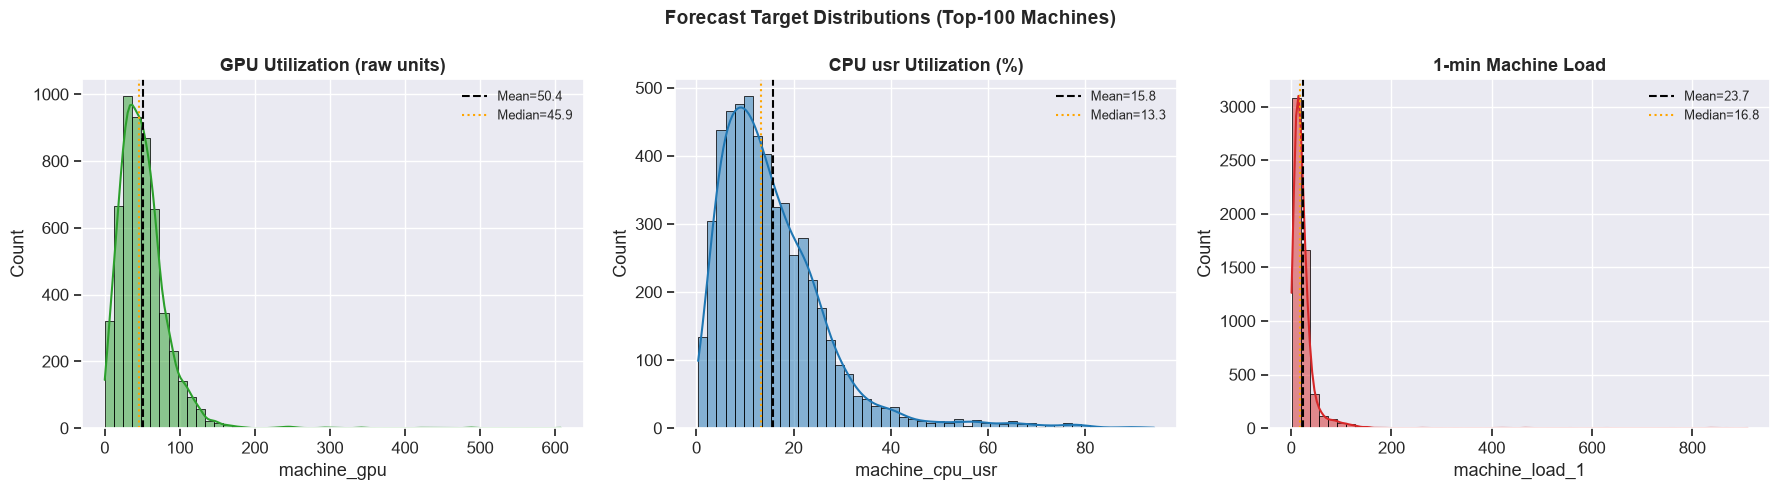

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Forecast Target Distributions (Top-100 Machines)", fontsize=14, fontweight="bold")

targets = [
    ("machine_gpu",     "GPU Utilization (raw units)",  "#2ca02c"),
    ("machine_cpu_usr", "CPU usr Utilization (%)",      "#1f77b4"),
    ("machine_load_1",  "1-min Machine Load",           "#d62728"),
]

for ax, (col, title, color) in zip(axes, targets):
    data = df_sample[col].dropna()
    sns.histplot(data, bins=50, ax=ax, color=color, kde=True)
    ax.axvline(data.mean(), color="black", linestyle="--", linewidth=1.5, label=f"Mean={data.mean():.1f}")
    ax.axvline(data.median(), color="orange", linestyle=":", linewidth=1.5, label=f"Median={data.median():.1f}")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/01_target_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

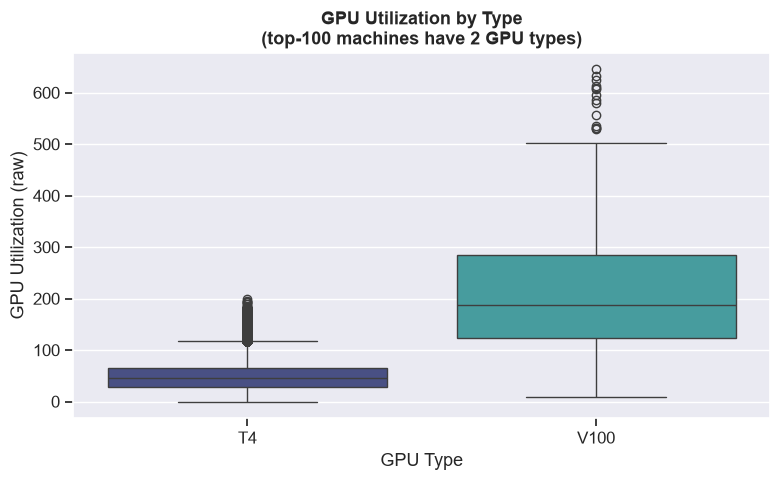

In [53]:
gpu_pdf = final_df.select(["gpu_type", "machine_gpu"]).to_pandas()

plt.figure(figsize=(8, 5))
sns.boxplot(data=gpu_pdf, x="gpu_type", y="machine_gpu", palette="mako")
plt.title(f"GPU Utilization by Type\n(top-100 machines have {final_df['gpu_type'].n_unique()} GPU types)",
          fontweight="bold")
plt.xlabel("GPU Type")
plt.ylabel("GPU Utilization (raw)")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/02_gpu_by_type.png", dpi=200, bbox_inches="tight")
plt.show()

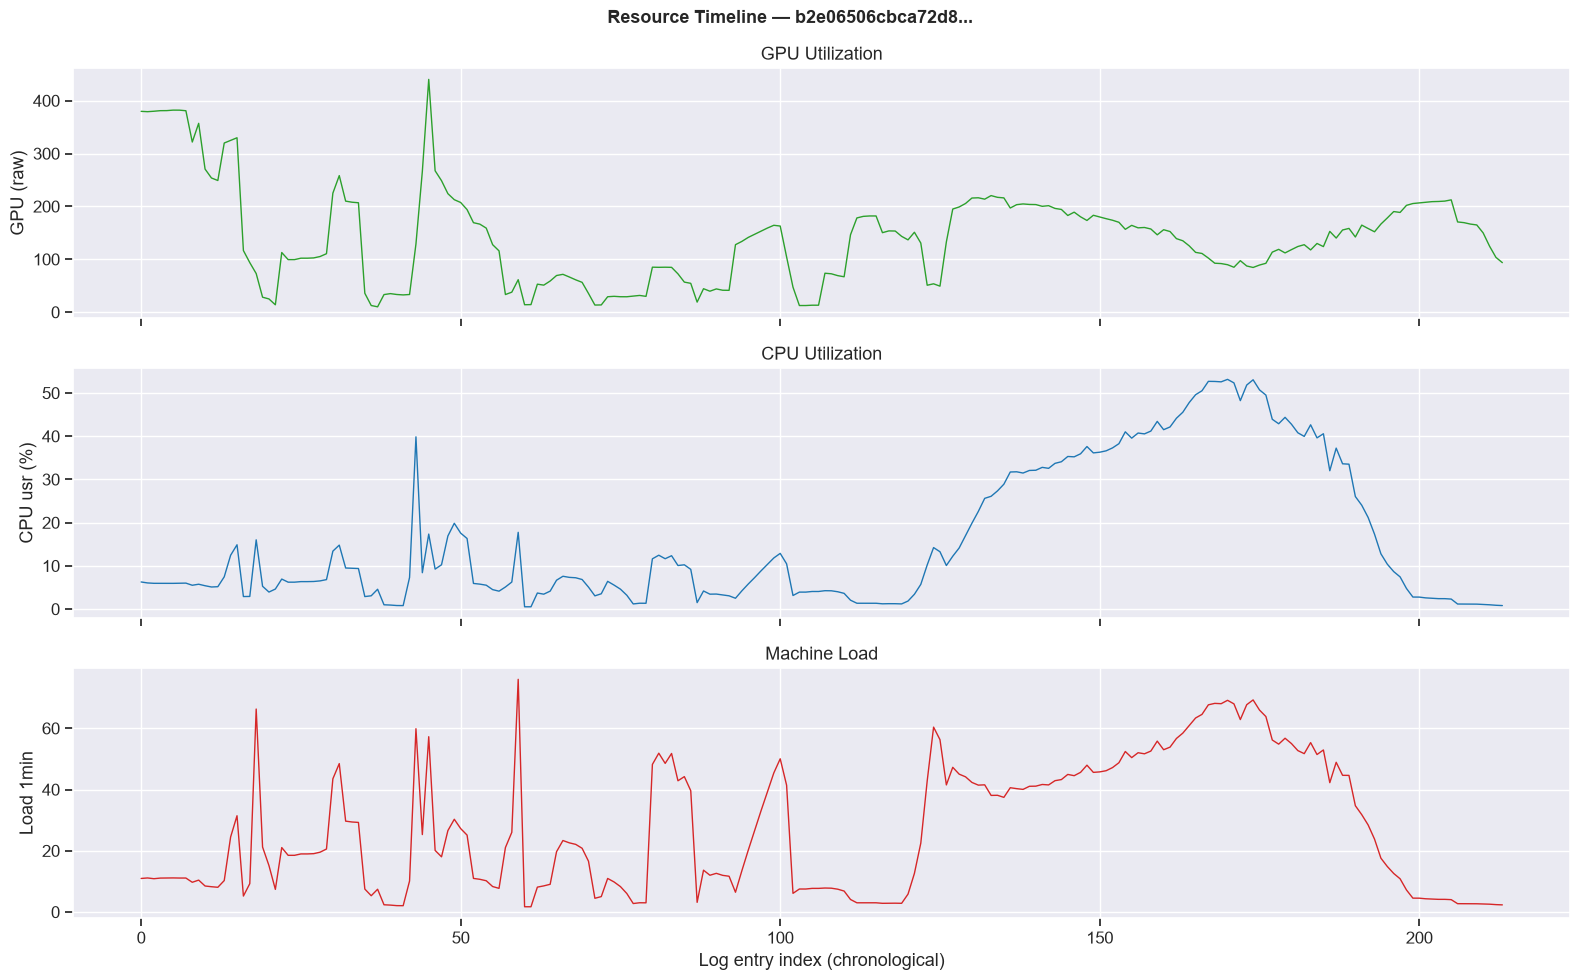

In [54]:
top_node    = golden_nodes[0]
timeline_df = (
    final_df
    .filter(pl.col("machine") == top_node)
    .sort("start_time")
    .head(500)
    .to_pandas()
)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle(f"Resource Timeline — {top_node[:16]}...", fontsize=13, fontweight="bold")

ax1.plot(timeline_df["machine_gpu"],     color="#2ca02c", linewidth=1)
ax1.set_ylabel("GPU (raw)")
ax1.set_title("GPU Utilization")

ax2.plot(timeline_df["machine_cpu_usr"], color="#1f77b4", linewidth=1)
ax2.set_ylabel("CPU usr (%)")
ax2.set_title("CPU Utilization")

ax3.plot(timeline_df["machine_load_1"],  color="#d62728", linewidth=1)
ax3.set_ylabel("Load 1min")
ax3.set_title("Machine Load")
ax3.set_xlabel("Log entry index (chronological)")

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/03_timeline_all_targets.png", dpi=200, bbox_inches="tight")
plt.show()

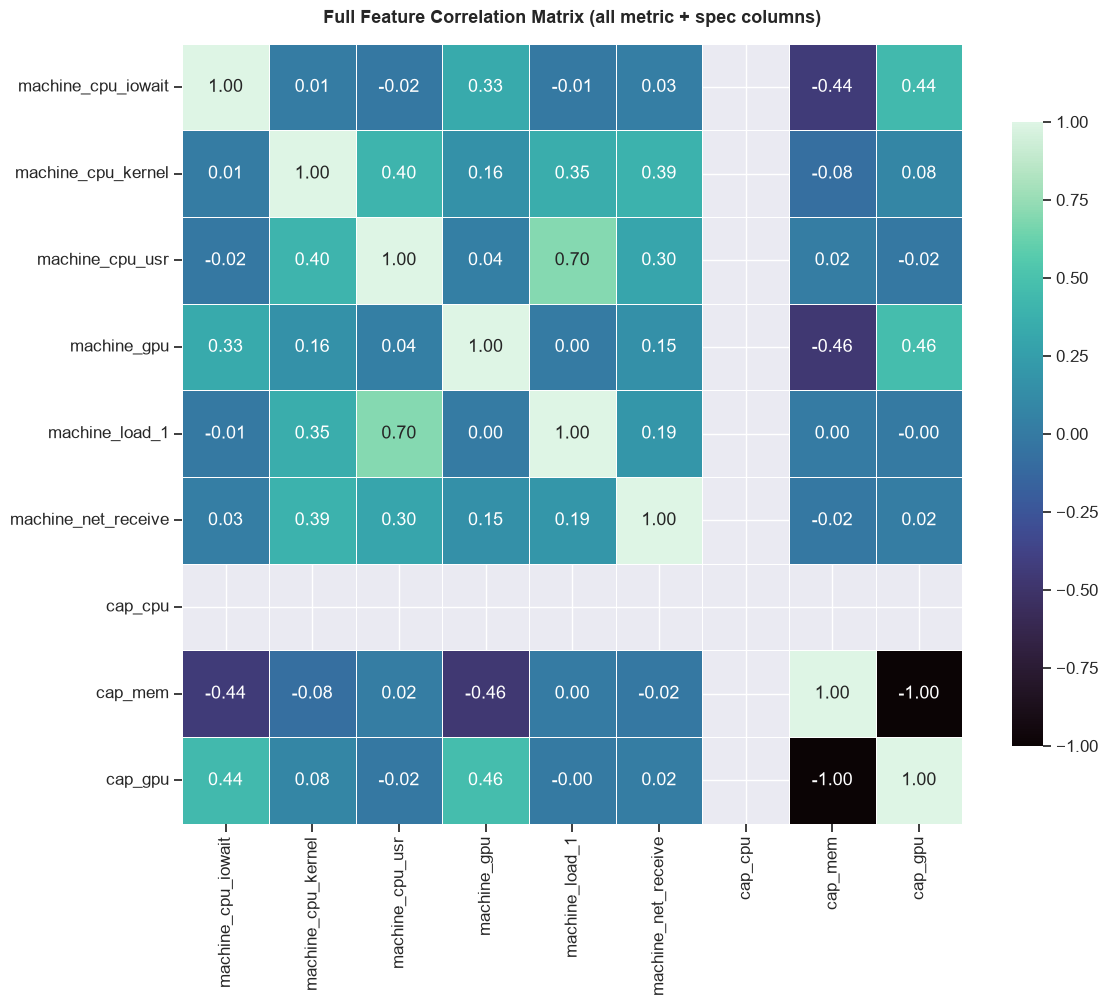

In [56]:
# All available metric + spec columns (excluding dropped columns)
all_metric_cols = [
    "machine_cpu_iowait", "machine_cpu_kernel", "machine_cpu_usr",
    "machine_gpu", "machine_load_1", "machine_net_receive",
    "cap_cpu", "cap_mem", "cap_gpu"
]

corr = df_sample[all_metric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="mako",
            linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8}, square=True)
plt.title("Full Feature Correlation Matrix (all metric + spec columns)", fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/04_full_correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

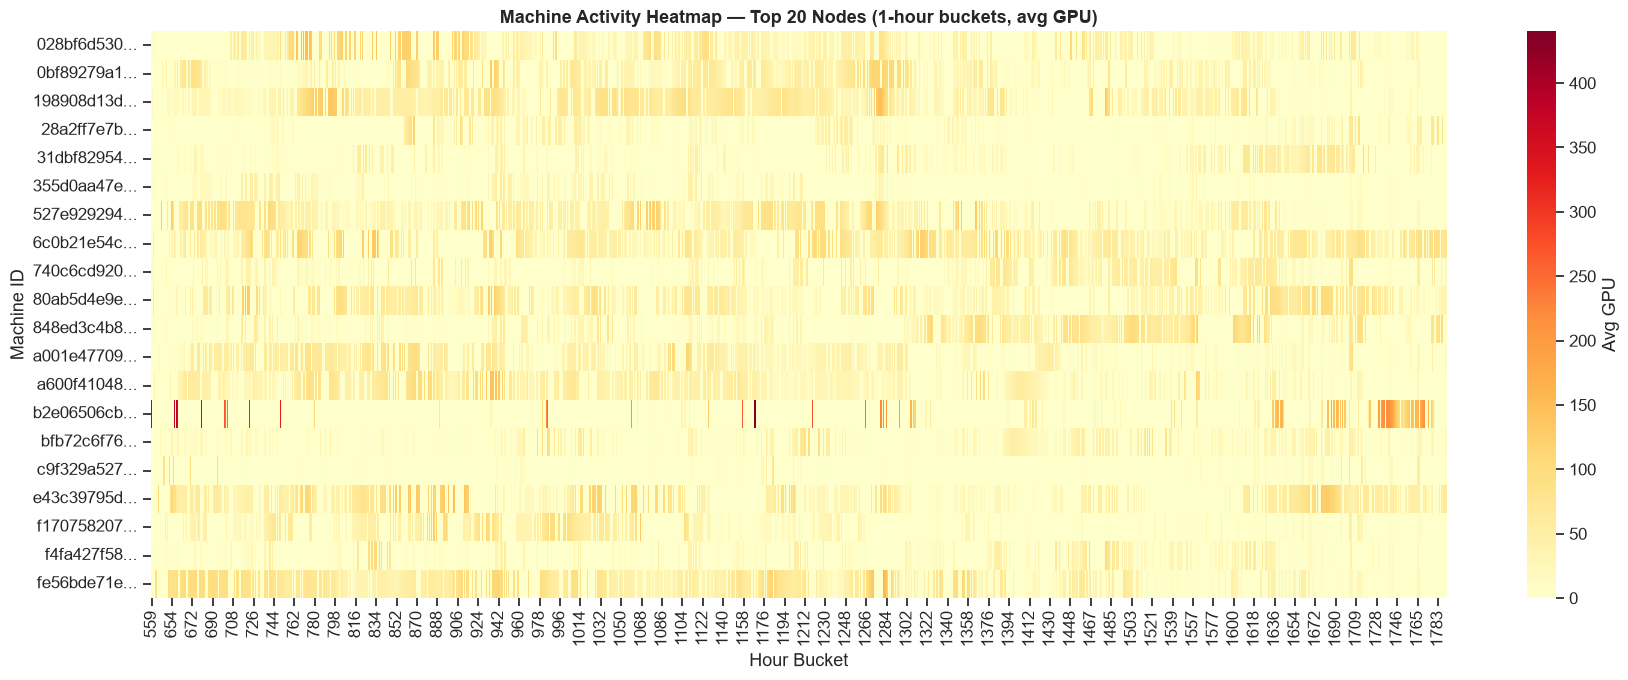

In [57]:
top20 = golden_nodes[:20]

heat_df = (
    final_df
    .filter(pl.col("machine").is_in(top20))
    .with_columns((pl.col("start_time") // 3600).alias("hour_bucket"))
    .group_by(["machine", "hour_bucket"])
    .agg(pl.col("machine_gpu").mean().alias("avg_gpu"))
    .sort(["machine", "hour_bucket"])
    .to_pandas()
    .pivot_table(index="machine", columns="hour_bucket", values="avg_gpu", fill_value=0)
)

heat_df.index = [m[:10] + "..." for m in heat_df.index]

plt.figure(figsize=(18, 7))
sns.heatmap(heat_df, cmap="YlOrRd", linewidths=0, cbar_kws={"label": "Avg GPU"})
plt.title("Machine Activity Heatmap — Top 20 Nodes (1-hour buckets, avg GPU)", fontweight="bold")
plt.xlabel("Hour Bucket")
plt.ylabel("Machine ID")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/05_machine_activity_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

In [59]:
print("=" * 55)
print("  NOTEBOOK 01 COMPLETE")
print("=" * 55)
print(f"  Raw rows             : {total_raw:,}")
print(f"  After target nulls   : {clean_count:,}  (-{total_raw - clean_count:,})")
print(f"  After top-100 filter : {final_df.shape[0]:,}")
print(f"  Machines             : {final_df['machine'].n_unique()}")
print(f"  Columns              : {final_df.shape[1]}  (14 — dropped 2 unused cols)")
print(f"  Nulls fixed          : iowait+net_receive → gpu_type mean")
print(f"  Columns dropped      : machine_num_worker, machine_cpu")
print(f"  Parquet saved        : {saved_mb:.2f} MB")
print(f"  EDA charts           : 5 PNGs → {REPORT_DIR}")
print("=" * 55)
print("\n✅ Ready for → 02_resampling__features.ipynb")

  NOTEBOOK 01 COMPLETE
  Raw rows             : 2,009,423
  After target nulls   : 1,630,839  (-378,584)
  After top-100 filter : 107,610
  Machines             : 100
  Columns              : 14  (14 — dropped 2 unused cols)
  Nulls fixed          : iowait+net_receive → gpu_type mean
  Columns dropped      : machine_num_worker, machine_cpu
  Parquet saved        : 9.61 MB
  EDA charts           : 5 PNGs → ../outputs/reports

✅ Ready for → 02_resampling__features.ipynb
